In [79]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [80]:
store_base_path = (
    os.path.dirname(os.path.abspath("")) + "/data/map_based_results/"   
)

In [81]:
original_data = np.load(store_base_path + "results_original.npz")
empty_16_data = np.load(store_base_path + "results_empty-16.npz")
empty_32_data = np.load(store_base_path + "results_empty-32.npz")
maze_32_data = np.load(store_base_path + "results_maze-32.npz")

In [82]:
def plot_box_plots(data, axis, title):

    bplot = axis.boxplot(data,
                            notch=False,
                            vert=True,
                            patch_artist=True)

    colors = ['pink', 'lightblue', 'lightgreen']
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    axis.set_title(title)
    axis.yaxis.grid(True)
    axis.set_xticks([y+1 for y in range(len(data))], )

    plt.setp(axis, xticks=[y+1 for y in range(len(data))],
            xticklabels=['SA-V', 'SA-V-CA', 'MA-V'])


### First GP step


Text(0.5, 0, 'Ablations')

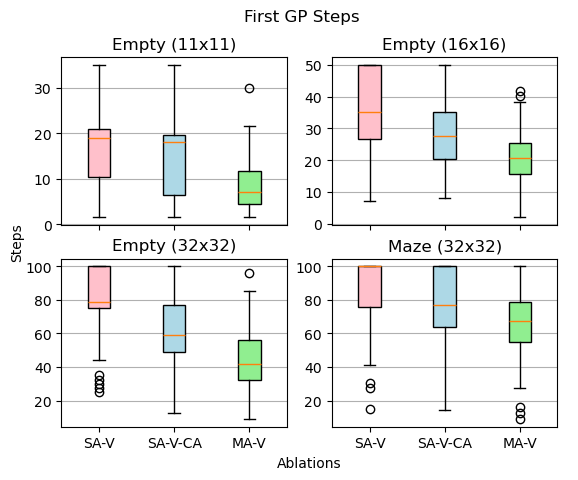

In [83]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)
plot_box_plots([original_data["single_agent_first_gp_steps"], original_data["single_agent_ca_first_gp_steps"], original_data["multi_agent_first_gp_steps"]], axes[0, 0], "Empty (11x11)")
plot_box_plots([empty_16_data["single_agent_first_gp_steps"], empty_16_data["single_agent_ca_first_gp_steps"], empty_16_data["multi_agent_first_gp_steps"]], axes[0, 1], "Empty (16x16)")
plot_box_plots([empty_32_data["single_agent_first_gp_steps"], empty_32_data["single_agent_ca_first_gp_steps"], empty_32_data["multi_agent_first_gp_steps"]], axes[1, 0], "Empty (32x32)")
plot_box_plots([maze_32_data["single_agent_first_gp_steps"], maze_32_data["single_agent_ca_first_gp_steps"], maze_32_data["multi_agent_first_gp_steps"]], axes[1, 1], "Maze (32x32)")
fig.suptitle("First GP Steps")
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.ylabel("Steps")
plt.xlabel("Ablations")

### Number of GPs discovered

Text(0.5, 0, 'Ablations')

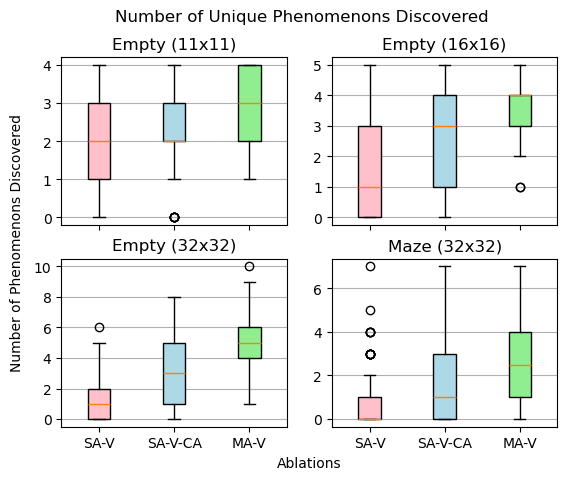

In [84]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)
plot_box_plots([original_data["single_agent_phenomenons_discovered"], original_data["single_agent_ca_phenomenons_discovered"], original_data["multi_agent_phenomenons_discovered"]], axes[0, 0], "Empty (11x11)")
plot_box_plots([empty_16_data["single_agent_phenomenons_discovered"], empty_16_data["single_agent_ca_phenomenons_discovered"], empty_16_data["multi_agent_phenomenons_discovered"]], axes[0, 1], "Empty (16x16)")
plot_box_plots([empty_32_data["single_agent_phenomenons_discovered"], empty_32_data["single_agent_ca_phenomenons_discovered"], empty_32_data["multi_agent_phenomenons_discovered"]], axes[1, 0], "Empty (32x32)")
plot_box_plots([maze_32_data["single_agent_phenomenons_discovered"], maze_32_data["single_agent_ca_phenomenons_discovered"], maze_32_data["multi_agent_phenomenons_discovered"]], axes[1, 1], "Maze (32x32)")
fig.suptitle("Number of Unique Phenomenons Discovered")
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.ylabel("Number of Phenomenons Discovered")
plt.xlabel("Ablations")

### Nodes Analysis

Text(0.5, 0, '\n\nMaps')

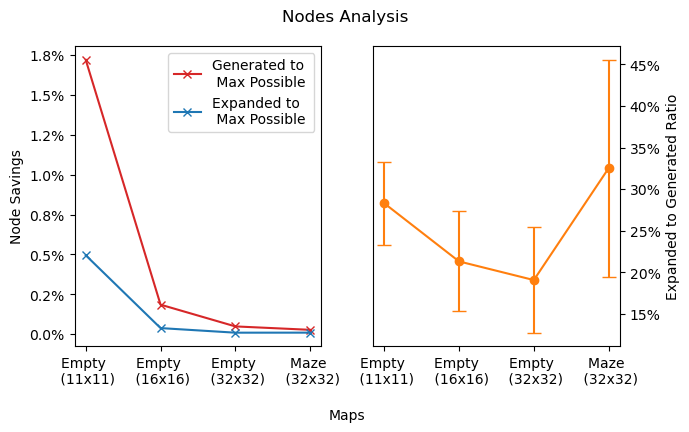

In [85]:
from matplotlib.ticker import FuncFormatter
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(7, 4))

original_gen_to_max = original_data["max_possible_nodes_data"][0] / original_data["max_possible_nodes_data"][-1]
empty_16_gen_to_max = empty_16_data["max_possible_nodes_data"][0] / empty_16_data["max_possible_nodes_data"][-1]
empty_32_gen_to_max = empty_32_data["max_possible_nodes_data"][0] / empty_32_data["max_possible_nodes_data"][-1]
maze_32_gen_to_max = maze_32_data["max_possible_nodes_data"][0] / maze_32_data["max_possible_nodes_data"][-1]

original_exp_to_max = original_data["max_possible_nodes_data"][1] / original_data["max_possible_nodes_data"][-1]
empty_16_exp_to_max = empty_16_data["max_possible_nodes_data"][1] / empty_16_data["max_possible_nodes_data"][-1]
empty_32_exp_to_max = empty_32_data["max_possible_nodes_data"][1] / empty_32_data["max_possible_nodes_data"][-1]
maze_32_exp_to_max = maze_32_data["max_possible_nodes_data"][1] / maze_32_data["max_possible_nodes_data"][-1]

axes[0].set_ylabel('Node Savings')
axes[0].plot(np.arange(4), [original_gen_to_max, empty_16_gen_to_max, empty_32_gen_to_max, maze_32_gen_to_max], color='tab:red', marker="x", label = "Generated to \n Max Possible")
axes[0].plot(np.arange(4), [original_exp_to_max, empty_16_exp_to_max, empty_32_exp_to_max, maze_32_exp_to_max], color='tab:blue', marker="x", label = "Expanded to \n Max Possible")
axes[0].tick_params(axis='y')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
axes[0].legend()

original_ratio_mean, original_ratio_std = np.mean(original_data["ratios"]), np.std(original_data["ratios"])
empty_16_ratio_mean, empty_16_ratio_std = np.mean(empty_16_data["ratios"]), np.std(empty_16_data["ratios"])
empty_32_ratio_mean, empty_32_ratio_std = np.mean(empty_32_data["ratios"]), np.std(empty_32_data["ratios"])
maze_32_ratio_mean, maze_32_ratio_std = np.mean(maze_32_data["ratios"]), np.std(maze_32_data["ratios"])

axes[1].set_ylabel('Expanded to Generated Ratio')
axes[1].errorbar(np.arange(4), [original_ratio_mean, empty_16_ratio_mean, empty_32_ratio_mean, maze_32_ratio_mean], [original_ratio_std, empty_16_ratio_std, empty_32_ratio_std, maze_32_ratio_std], fmt='o-', capsize=5, color='tab:orange')
axes[1].tick_params(axis='y')
axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

plt.setp(axes[0], xticks=[y for y in range(4)],
        xticklabels=['Empty \n (11x11)', 'Empty \n (16x16)', 'Empty \n (32x32)', 'Maze \n (32x32)'])

fig.suptitle("Nodes Analysis")
fig.tight_layout()
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("\n\nMaps")